In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Load Kaggle dataset
data = pd.read_csv('train.csv')

# Select feature and target
X = data[['GrLivArea']]
y = data['SalePrice']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# Predict a new house
new_house = [[2000]]
predicted_price = model.predict(new_house)
print("Predicted Price:", predicted_price[0])


R2 Score: 0.5542632452871117
MSE: 3418946311.180807
Predicted Price: 229877.66599078485


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


R² Score: 0.7833463107364539


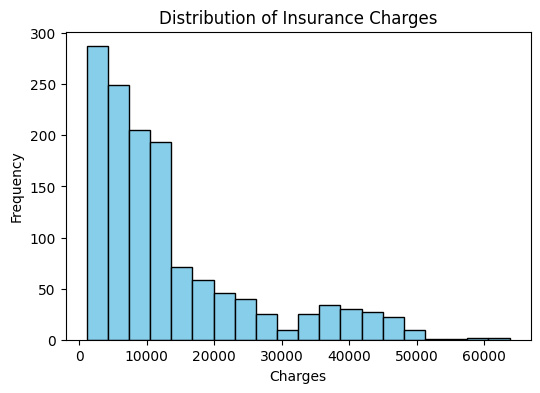

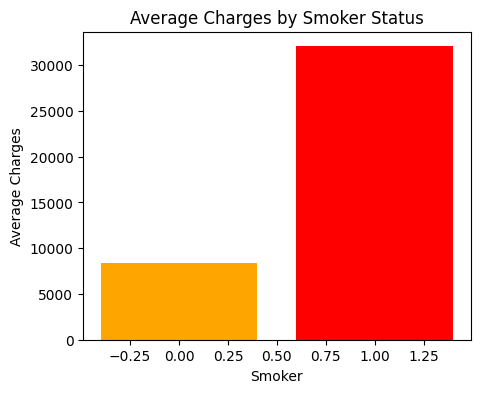

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("insurance.csv")

# Convert categorical data to numbers
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

# Features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Accuracy
print("R² Score:", model.score(X_test, y_test))

# 1. Histogram of Charges
plt.figure(figsize=(6,4))
plt.hist(df['charges'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

# 2. Bar Chart: Average Charges by Smoker Status
avg_charges = df.groupby('smoker')['charges'].mean()

plt.figure(figsize=(5,4))
plt.bar(avg_charges.index, avg_charges.values, color=['orange', 'red'])
plt.title('Average Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Average Charges')
plt.show()